In [2]:
#Steps to do it

#1. CHoose K
#2. Choose K centroids
    # Randonly choose K indices from the number of samples.
    # Choose the samples of these indices
#3. Calculate the distance for samples and all centroids
#4. Assign Clusters
#5. Recalculate Centroids
#6. converging or not (if centroids are the same as the old ones then converge or else restart from step 3)

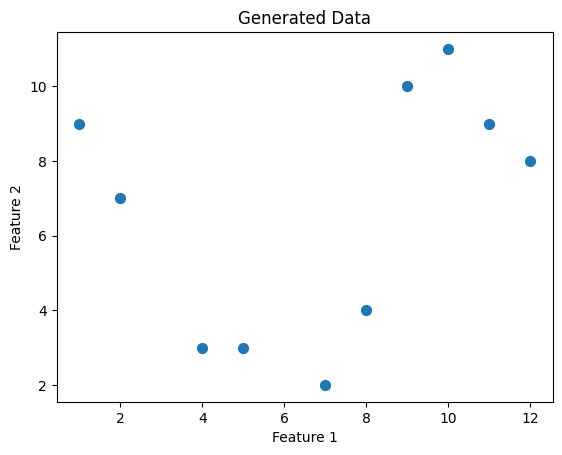

In [31]:
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib import pyplot as plt

X = np.array([[1,9],
              [2,7],
              [4,3],
              [5,3],
              [7,2],
              [8,4],
              [10,11],
              [11,9],
              [9,10],
              [12,8]])

plt.scatter(X[:,0], X[:,1], s=50)
plt.title("Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
def EuclideanDistance(x1, x2):
    ED = np.sqrt(np.sum((x1 - x2)**2))
    return ED

class KMeans:
  def __init__(self, k = 5, max_iters = 100):
    self.k = k
    self.max_iters = max_iters
    self.clusters = None
    self.centroids = []

  def fit(self, X):
    self.centroids = []
    self.X = X
    self.n_samples, self.n_features = X.shape
    indices = np.random.choice(self.n_samples, self.k, replace = False)
    for index in indices:
      self.centroids.append(X[index])

    for i in range(self.max_iters):
      self.clusters = self.create_clusters(self.centroids)
      centroids_old = self.centroids
      self.centroids = self.get_centroids(self.clusters)
      if self.is_converged(centroids_old, self.centroids):
        break
    return self.get_cluster_labels(self.clusters)

  def get_cluster_labels(self, clusters):
    labels = np.empty(self.n_samples)
    for cluster_index, cluster in enumerate(clusters):
      for row in cluster:
        labels[row] = cluster_index
    return labels


  def create_clusters(self, centroids):
    clusters = []
    for i in range(self.k):
      clusters.append([])
    for index, sample in enumerate(self.X):
      closest_index = self.closest_centroid(sample, centroids)
      clusters[closest_index].append(index)
    return clusters


  def closest_centroid(self, sample, centroids):
    distances = []
    for centroid in centroids:
      distance = EuclideanDistance(sample, centroid)
      distances.append(distance)
    return np.argmin(distances)


  def get_centroids(self, clusters):
    new_centroids = []
    for cluster in clusters:
      new_centroid = np.mean(self.X[cluster], axis = 0)
      new_centroids.append(new_centroid)
    return new_centroids


  def is_converged(self, centroids_old, centroids):
    distance = 0
    tolerance = 0.0001
    for i in range(self.k):
        dist = EuclideanDistance(centroids_old[i], centroids[i])
        distance += dist
    if distance < tolerance:
      return True
    return False

  def predict(self, X):
    pass

y_pred: [2 2 0 0 0 0 1 1 1 1]


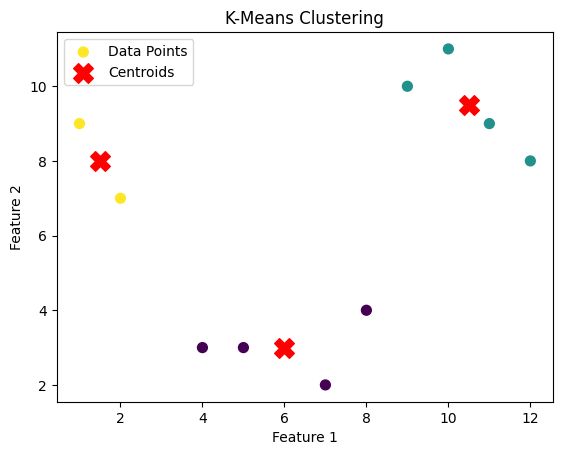

In [39]:
model = KMeans(n_clusters = 3, random_state=42)
model.fit(X)
y_pred = model.predict(X)
print("y_pred:", y_pred)

plt.scatter(X[:,0], X[:,1], s=50, c=y_pred, cmap='viridis', label = "Data Points")
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=200, c='red', marker = 'X', label = "Centroids")
plt.legend()
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [42]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters = 3, random_state=42)
model.fit(X)
y_pred = model.predict(X)
print("y_pred:", y_pred)
print("centroids:", model.cluster_centers_)


y_pred: [2 2 0 0 0 0 1 1 1 1]
centroids: [[ 6.   3. ]
 [10.5  9.5]
 [ 1.5  8. ]]
